In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.rcParams['figure.figsize'] = (14, 5)
plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

print("OK")

OK


In [2]:
DATA_PATH = Path("/workspaces/industrial-ai-predictive-maintenance/data/raw/CMAPSS")

# Colonnes du dataset
cols = ['unit', 'cycle', 'op1', 'op2', 'op3'] + [f's{i}' for i in range(1, 22)]

df_train = pd.read_csv(DATA_PATH / "train_FD001.txt", sep="\s+", header=None, names=cols)
df_test  = pd.read_csv(DATA_PATH / "test_FD001.txt",  sep="\s+", header=None, names=cols)
rul_test  = pd.read_csv(DATA_PATH / "RUL_FD001.txt",  sep="\s+", header=None, names=['RUL'])

print(f"Train shape : {df_train.shape}")
print(f"Test shape  : {df_test.shape}")
print(f"Unités train : {df_train['unit'].nunique()} moteurs")
print(f"Unités test  : {df_test['unit'].nunique()} moteurs")
print(f"Cycles min/max train : {df_train['cycle'].min()} / {df_train['cycle'].max()}")
print(f"\nPremières lignes :")
print(df_train.head(3))

<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_7400/2450803559.py:6: SyntaxWarning: invalid escape sequence '\s'
  df_train = pd.read_csv(DATA_PATH / "train_FD001.txt", sep="\s+", header=None, names=cols)
/tmp/ipykernel_7400/2450803559.py:7: SyntaxWarning: invalid escape sequence '\s'
  df_test  = pd.read_csv(DATA_PATH / "test_FD001.txt",  sep="\s+", header=None, names=cols)
/tmp/ipykernel_7400/2450803559.py:8: SyntaxWarning: invalid escape sequence '\s'
  rul_test  = pd.read_csv(DATA_PATH / "RUL_FD001.txt",  sep="\s+", header=None, names=['RUL'])


Train shape : (20631, 26)
Test shape  : (13096, 26)
Unités train : 100 moteurs
Unités test  : 100 moteurs
Cycles min/max train : 1 / 362

Premières lignes :
   unit  cycle     op1     op2    op3      s1      s2       s3       s4  \
0     1      1 -0.0007 -0.0004  100.0  518.67  641.82  1589.70  1400.60   
1     1      2  0.0019 -0.0003  100.0  518.67  642.15  1591.82  1403.14   
2     1      3 -0.0043  0.0003  100.0  518.67  642.35  1587.99  1404.20   

      s5  ...     s12      s13      s14     s15   s16  s17   s18    s19  \
0  14.62  ...  521.66  2388.02  8138.62  8.4195  0.03  392  2388  100.0   
1  14.62  ...  522.28  2388.07  8131.49  8.4318  0.03  392  2388  100.0   
2  14.62  ...  522.42  2388.03  8133.23  8.4178  0.03  390  2388  100.0   

     s20      s21  
0  39.06  23.4190  
1  39.00  23.4236  
2  38.95  23.3442  

[3 rows x 26 columns]


RUL min : 0
RUL max : 361
RUL moyen : 107.8 cycles


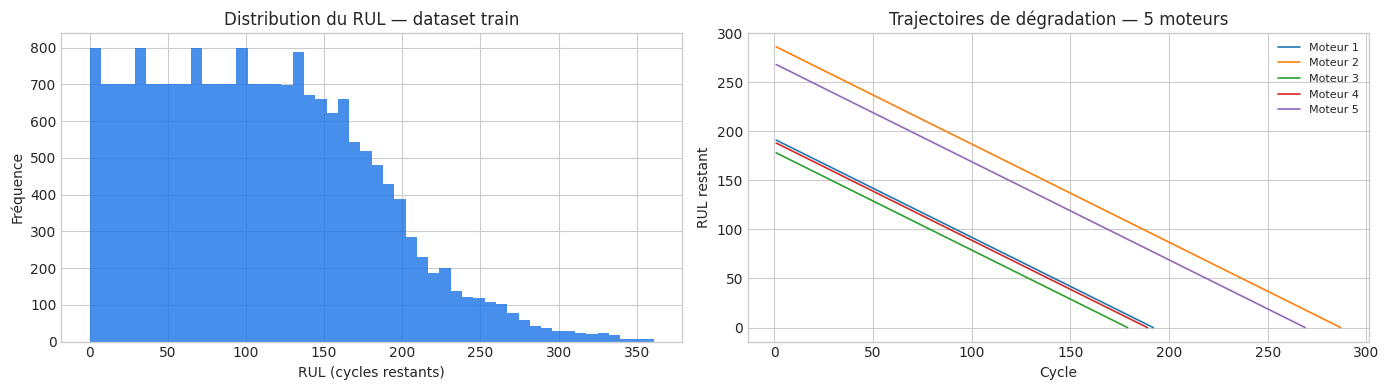

OK


In [3]:
# RUL = nombre de cycles restants avant la défaillance
# Pour chaque unité, RUL = max_cycle - cycle_actuel
max_cycles = df_train.groupby('unit')['cycle'].max().reset_index()
max_cycles.columns = ['unit', 'max_cycle']

df_train = df_train.merge(max_cycles, on='unit')
df_train['RUL'] = df_train['max_cycle'] - df_train['cycle']
df_train.drop(columns=['max_cycle'], inplace=True)

print(f"RUL min : {df_train['RUL'].min()}")
print(f"RUL max : {df_train['RUL'].max()}")
print(f"RUL moyen : {df_train['RUL'].mean():.1f} cycles")

# Distribution du RUL
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df_train['RUL'], bins=50, color='#1a73e8', alpha=0.8)
axes[0].set_xlabel("RUL (cycles restants)")
axes[0].set_ylabel("Fréquence")
axes[0].set_title("Distribution du RUL — dataset train")

# Trajectoire de dégradation de 5 moteurs
for unit in range(1, 6):
    df_unit = df_train[df_train['unit'] == unit]
    axes[1].plot(df_unit['cycle'], df_unit['RUL'],
                 linewidth=1.2, label=f'Moteur {unit}')

axes[1].set_xlabel("Cycle")
axes[1].set_ylabel("RUL restant")
axes[1].set_title("Trajectoires de dégradation — 5 moteurs")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("/workspaces/industrial-ai-predictive-maintenance/notebooks/cmapss_rul_distribution.png",
            dpi=120, bbox_inches="tight")
plt.show()
print("OK")

Capteurs utiles (11) : ['s9', 's14', 's4', 's3', 's17', 's7', 's12', 's2', 's11', 's20', 's21']
Capteurs constants supprimés (10) : ['s13', 's8', 's15', 's6', 's5', 's16', 's1', 's10', 's19', 's18']


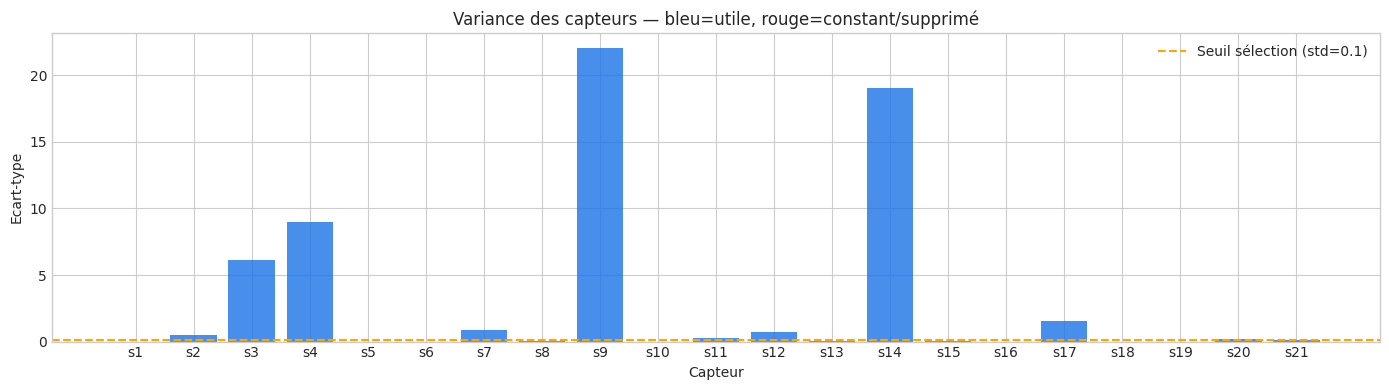


Capteurs retenus : ['s9', 's14', 's4', 's3', 's17', 's7', 's12', 's2', 's11', 's20', 's21']


In [4]:
# Certains capteurs CMAPSS sont constants — inutiles pour le modèle
sensor_cols = [f's{i}' for i in range(1, 22)]

# Calculer l'écart-type de chaque capteur
std_per_sensor = df_train[sensor_cols].std().sort_values(ascending=False)

# Garder uniquement les capteurs avec std > 0.1
useful_sensors = std_per_sensor[std_per_sensor > 0.1].index.tolist()
dropped_sensors = std_per_sensor[std_per_sensor <= 0.1].index.tolist()

print(f"Capteurs utiles ({len(useful_sensors)}) : {useful_sensors}")
print(f"Capteurs constants supprimés ({len(dropped_sensors)}) : {dropped_sensors}")

# Visualiser la variance de chaque capteur
fig, ax = plt.subplots(figsize=(14, 4))
colors = ['#1a73e8' if s in useful_sensors else '#e53935' for s in sensor_cols]
ax.bar(sensor_cols, std_per_sensor[sensor_cols], color=colors, alpha=0.8)
ax.axhline(0.1, color='orange', linestyle='--', linewidth=1.5, label='Seuil sélection (std=0.1)')
ax.set_xlabel("Capteur")
ax.set_ylabel("Ecart-type")
ax.set_title("Variance des capteurs — bleu=utile, rouge=constant/supprimé")
ax.legend()
plt.tight_layout()
plt.savefig("/workspaces/industrial-ai-predictive-maintenance/notebooks/cmapss_sensor_variance.png",
            dpi=120, bbox_inches="tight")
plt.show()
print(f"\nCapteurs retenus : {useful_sensors}")

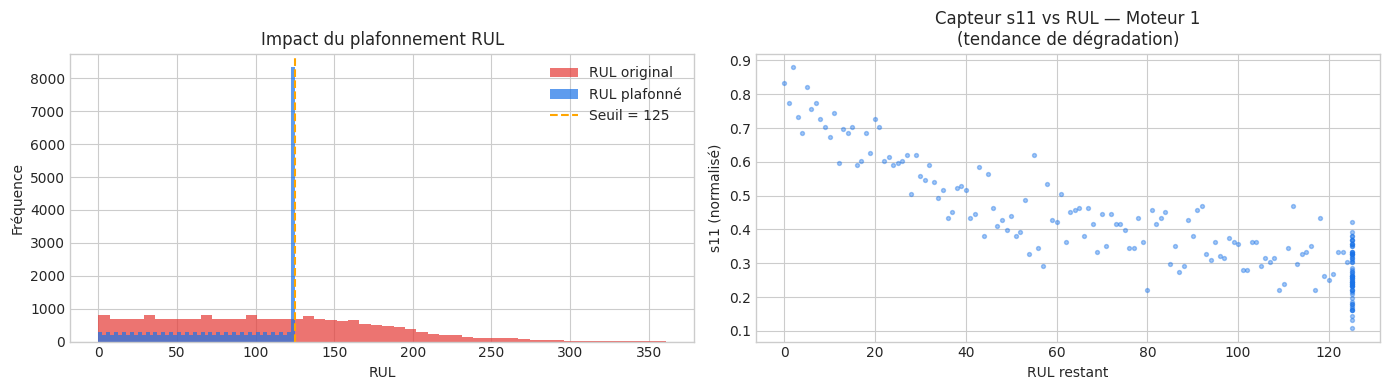

OK


In [5]:
from sklearn.preprocessing import MinMaxScaler

# Plafonner le RUL à 125 cycles — au-delà l'équipement est "neuf"
# c'est une pratique standard en maintenance prédictive
RUL_MAX = 125
df_train['RUL_clipped'] = df_train['RUL'].clip(upper=RUL_MAX)

# Normaliser les capteurs
scaler = MinMaxScaler()
df_train[useful_sensors] = scaler.fit_transform(df_train[useful_sensors])
df_test[useful_sensors]  = scaler.transform(df_test[useful_sensors])

# Visualiser l'effet du plafonnement
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df_train['RUL'],         bins=50, color='#e53935', alpha=0.7, label='RUL original')
axes[0].hist(df_train['RUL_clipped'], bins=50, color='#1a73e8', alpha=0.7, label='RUL plafonné')
axes[0].axvline(RUL_MAX, color='orange', linestyle='--', linewidth=1.5, label=f'Seuil = {RUL_MAX}')
axes[0].set_xlabel("RUL")
axes[0].set_ylabel("Fréquence")
axes[0].set_title("Impact du plafonnement RUL")
axes[0].legend()

# Evolution d'un capteur clé avec le RUL
unit1 = df_train[df_train['unit'] == 1].copy()
axes[1].scatter(unit1['RUL_clipped'], unit1['s11'],
                alpha=0.4, s=8, color='#1a73e8')
axes[1].set_xlabel("RUL restant")
axes[1].set_ylabel("s11 (normalisé)")
axes[1].set_title("Capteur s11 vs RUL — Moteur 1\n(tendance de dégradation)")

plt.tight_layout()
plt.savefig("/workspaces/industrial-ai-predictive-maintenance/notebooks/cmapss_rul_clipped.png",
            dpi=120, bbox_inches="tight")
plt.show()
print("OK")

In [6]:
WINDOW = 30  # 30 cycles de contexte

def make_rul_sequences(df, sensor_cols, window, rul_col='RUL_clipped'):
    X, y = [], []
    for unit in df['unit'].unique():
        df_unit = df[df['unit'] == unit].sort_values('cycle')
        data    = df_unit[sensor_cols].values
        rul     = df_unit[rul_col].values
        for i in range(len(data) - window + 1):
            X.append(data[i:i+window])
            y.append(rul[i+window-1])
    return np.array(X), np.array(y)

X_train, y_train = make_rul_sequences(df_train, useful_sensors, WINDOW)

# Pour le test : prendre uniquement la dernière séquence de chaque moteur
def make_test_sequences(df, sensor_cols, window):
    X = []
    for unit in sorted(df['unit'].unique()):
        df_unit = df[df['unit'] == unit].sort_values('cycle')
        data    = df_unit[sensor_cols].values
        if len(data) >= window:
            X.append(data[-window:])
        else:
            # Padding si le moteur a moins de cycles que la fenêtre
            pad = np.zeros((window - len(data), len(sensor_cols)))
            X.append(np.vstack([pad, data]))
    return np.array(X)

X_test  = make_test_sequences(df_test, useful_sensors, WINDOW)
y_test  = rul_test['RUL'].values

print(f"X_train : {X_train.shape} — (sequences, timesteps, features)")
print(f"y_train : {y_train.shape} — RUL cible")
print(f"X_test  : {X_test.shape}")
print(f"y_test  : {y_test.shape}")
print(f"\nRUL test — min: {y_test.min()}, max: {y_test.max()}, mean: {y_test.mean():.1f}")

X_train : (17731, 30, 11) — (sequences, timesteps, features)
y_train : (17731,) — RUL cible
X_test  : (100, 30, 11)
y_test  : (100,)

RUL test — min: 7, max: 145, mean: 75.5


In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

tf.random.set_seed(42)

def build_lstm_rul(timesteps, n_features):
    model = Sequential([
        LSTM(128, input_shape=(timesteps, n_features),
             return_sequences=True, activation='tanh'),
        Dropout(0.2),
        LSTM(64, return_sequences=False, activation='tanh'),
        Dropout(0.2),
        BatchNormalization(),
        Dense(32, activation='relu'),
        Dense(1, activation='relu')  # RUL >= 0
    ])
    model.compile(optimizer='adam', loss='mse',
                  metrics=['mae'])
    return model

model_rul = build_lstm_rul(WINDOW, len(useful_sensors))
model_rul.summary()

I0000 00:00:1776087601.752697    7400 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776087622.860172    7400 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776087634.627184    7400 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/workspaces/industrial-ai-predictive-maintenance/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWa

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 128)        │        71,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,457 (482.25 KB)

 Trainable params: 123,329 (481.75 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 12s 139ms/step - loss: 7060.1499 - mae: 74.5612 - val_loss: 5824.2539 - val_mae: 67.2810 - learning_rate: 0.0010
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 7s 125ms/step - loss: 4737.7720 - mae: 60.0590 - val_loss: 4065.2068 - val_mae: 56.5237 - learning_rate: 0.0010
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 7s 120ms/step - loss: 1995.1427 - mae: 38.1193 - val_loss: 1987.3530 - val_mae: 38.4468 - learning_rate: 0.0010
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 7s 121ms/step - loss: 736.8939 - mae: 22.3357 - val_loss: 1176.0438 - val_mae: 29.7133 - learning_rate: 0.0010
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 7s 123ms/step - loss: 411.7749 - mae: 16.7481 - val_loss: 900.3846 - val_mae: 25.7064 - learning_rate: 0.0010
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 7s 127ms/step - loss: 346.2975 - mae: 15.2196 - val_loss: 516.2413 - val_mae: 19.5330 - learning_rate: 0.0010
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 8s 127ms/step - loss: 314.6258 - mae: 14.3766 - val_loss: 537.5093

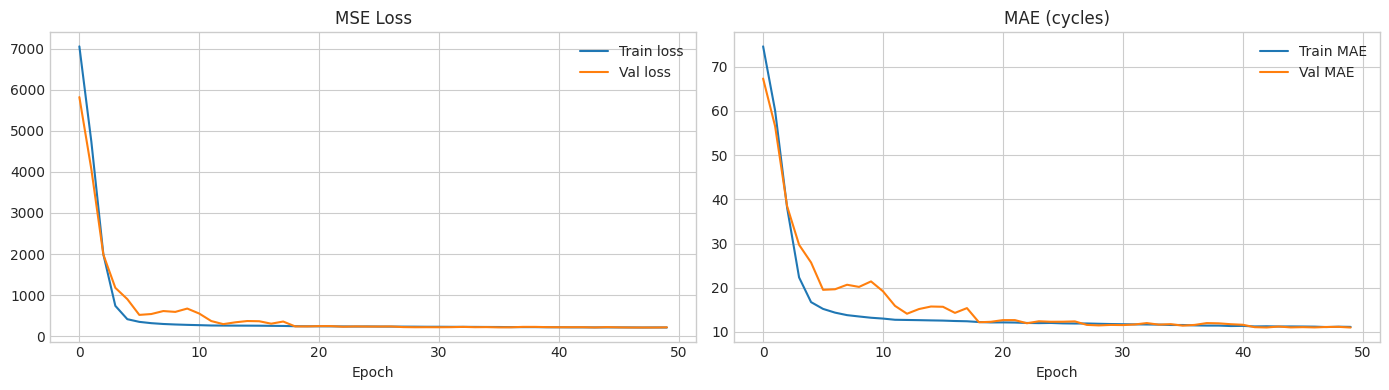

OK


In [8]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=5, min_lr=1e-5, verbose=1)
]

history = model_rul.fit(
    X_train, y_train,
    epochs=50,
    batch_size=256,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['loss'],     label='Train loss')
axes[0].plot(history.history['val_loss'], label='Val loss')
axes[0].set_title("MSE Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history['mae'],     label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Val MAE')
axes[1].set_title("MAE (cycles)")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig("/workspaces/industrial-ai-predictive-maintenance/notebooks/cmapss_training.png",
            dpi=120, bbox_inches="tight")
plt.show()
print("OK")

In [9]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

y_pred = model_rul.predict(X_test, verbose=0).flatten()

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)

print(f"RMSE : {rmse:.2f} cycles")
print(f"MAE  : {mae:.2f} cycles")
print(f"\nExemples de prédictions :")
comparison = pd.DataFrame({
    'RUL_reel'  : y_test[:10],
    'RUL_predit': y_pred[:10].round(1),
    'erreur'    : (y_pred[:10] - y_test[:10]).round(1)
})
print(comparison.to_string(index=False))

RMSE : 16.42 cycles
MAE  : 12.90 cycles

Exemples de prédictions :
 RUL_reel  RUL_predit  erreur
      112  121.599998     9.6
       98  126.500000    28.5
       69   50.400002   -18.6
       82   86.599998     4.6
       91  112.000000    21.0
       93  115.599998    22.6
       91  100.099998     9.1
       95  101.900002     6.9
      111  131.800003    20.8
       96   94.000000    -2.0


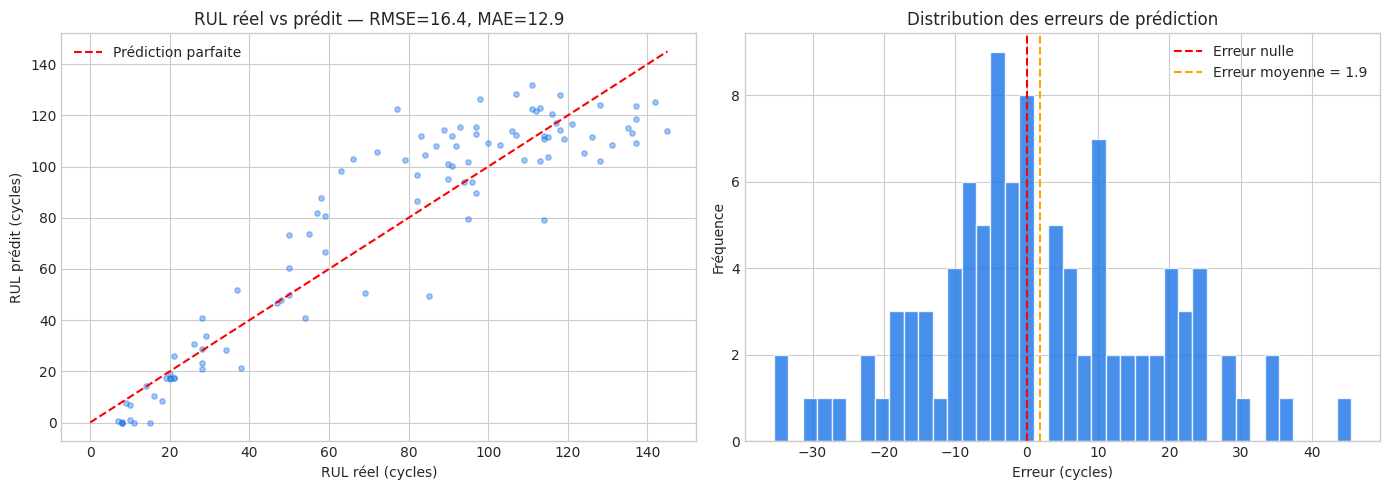

OK


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter réel vs prédit
axes[0].scatter(y_test, y_pred, alpha=0.4, s=15, color='#1a73e8')
lim = max(y_test.max(), y_pred.max())
axes[0].plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Prédiction parfaite')
axes[0].set_xlabel("RUL réel (cycles)")
axes[0].set_ylabel("RUL prédit (cycles)")
axes[0].set_title(f"RUL réel vs prédit — RMSE={rmse:.1f}, MAE={mae:.1f}")
axes[0].legend()

# Distribution des erreurs
errors = y_pred - y_test
axes[1].hist(errors, bins=40, color='#1a73e8', alpha=0.8, edgecolor='white')
axes[1].axvline(0,            color='red',    linestyle='--', linewidth=1.5, label='Erreur nulle')
axes[1].axvline(errors.mean(), color='orange', linestyle='--', linewidth=1.5,
                label=f'Erreur moyenne = {errors.mean():.1f}')
axes[1].set_xlabel("Erreur (cycles)")
axes[1].set_ylabel("Fréquence")
axes[1].set_title("Distribution des erreurs de prédiction")
axes[1].legend()

plt.tight_layout()
plt.savefig("/workspaces/industrial-ai-predictive-maintenance/notebooks/cmapss_predictions.png",
            dpi=120, bbox_inches="tight")
plt.show()
print("OK")

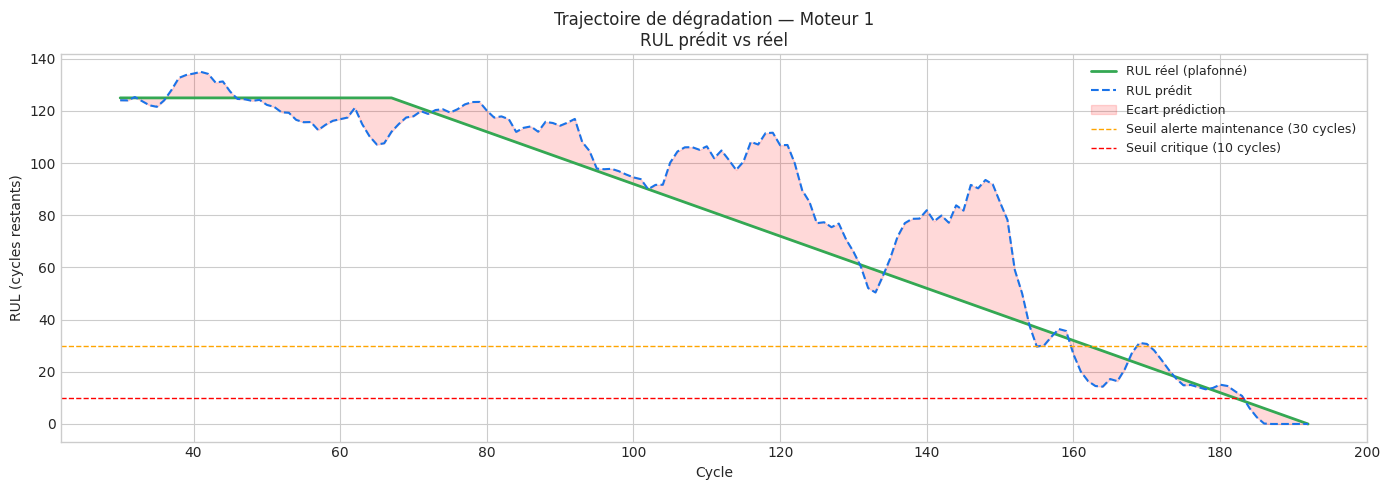

OK


In [11]:
# Prédire le RUL sur toute la trajectoire d'un moteur du train
unit_id = 1
df_unit = df_train[df_train['unit'] == unit_id].sort_values('cycle')
data_unit = df_unit[useful_sensors].values

# Séquences glissantes sur toute la vie du moteur
X_traj, cycles_traj = [], []
for i in range(len(data_unit) - WINDOW + 1):
    X_traj.append(data_unit[i:i+WINDOW])
    cycles_traj.append(df_unit['cycle'].values[i+WINDOW-1])

X_traj = np.array(X_traj)
rul_pred_traj = model_rul.predict(X_traj, verbose=0).flatten()
rul_true_traj = df_unit['RUL_clipped'].values[WINDOW-1:]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(cycles_traj, rul_true_traj, linewidth=2,
        color='#34a853', label='RUL réel (plafonné)')
ax.plot(cycles_traj, rul_pred_traj, linewidth=1.5,
        color='#1a73e8', linestyle='--', label='RUL prédit')
ax.fill_between(cycles_traj, rul_pred_traj, rul_true_traj,
                alpha=0.15, color='red', label='Ecart prédiction')
ax.axhline(30, color='orange', linestyle='--', linewidth=1,
           label='Seuil alerte maintenance (30 cycles)')
ax.axhline(10, color='red',    linestyle='--', linewidth=1,
           label='Seuil critique (10 cycles)')
ax.set_xlabel("Cycle")
ax.set_ylabel("RUL (cycles restants)")
ax.set_title(f"Trajectoire de dégradation — Moteur {unit_id}\nRUL prédit vs réel")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("/workspaces/industrial-ai-predictive-maintenance/notebooks/cmapss_trajectory.png",
            dpi=120, bbox_inches="tight")
plt.show()
print("OK")